# 實驗數據與分析 (Black & White Print-Friendly Version)

我們透過方波用來週期性地開/關 RF 場，在RF場關閉的時候，把大量粒子抽到最高 M sublevel，當RF場開啟的時後，就會產生如實驗原理所說的Ringing Effect（拉莫進動振盪），我們得到的在RF頻率為90kHz最大值為2VPP以及sweep field 對準 $\text{Rb}^{85}$ 的吸收點時，使用示波器取得了下列圖表。

In [2]:
# ── 全域 imports 與設定 ──────────────────────────────────────
import os
import sys
import glob
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from uncertainties import correlated_values
from IPython.display import display

# 確保能讀取到 src 內的模組
sys.path.append(os.path.abspath(".."))

from src.visualization.plot_settings import create_figure, apply_plot_style, save_figure

import src.analysis.fitting

importlib.reload(src.analysis.fitting)
from src.analysis.fitting import inverse_linear_regression_with_propagation

import src.analysis.formatting

importlib.reload(src.analysis.formatting)
from src.analysis.formatting import ufloat_to_paren

# ── 共用常數 ─────────────────────────────────────────────────
DATA_DIR = "../data/raw/D2_Optical_Pumping/0402/"
FIG_DIR = "../reports/figures"
DOWNSAMPLE_TARGET = 20_000

In [3]:
# ── 共用工具函式 ──────────────────────────────────────────────


def load_oscilloscope_csv(filepath: str) -> pd.DataFrame:
    """讀取示波器輸出的 CSV 檔，自動處理常見的標頭格式問題。"""
    try:
        df = pd.read_csv(filepath, comment="#")
    except pd.errors.ParserError:
        df = pd.read_csv(filepath, skiprows=15)
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df.dropna()


def damped_sine(t, A, gamma, f, phi, C):
    """阻尼正弦波模型: A·exp(-γt)·sin(2πft + φ) + C"""
    return A * np.exp(-gamma * t) * np.sin(2 * np.pi * f * t + phi) + C


def optical_pumping_model(t, C, A, tau_p):
    """光抽運指數回復模型: I(t) = C - A·exp(-t/τ_p)"""
    return C - A * np.exp(-t / tau_p)

In [4]:
# ══════════════════════════════════════════════════════════════
# 黑白列印友好設定
# ══════════════════════════════════════════════════════════════
# CH1 / CH2 線條：用灰度 + 線型區分
STYLE_CH1 = dict(color="0.60", linewidth=1.2, linestyle="-", alpha=0.8)  # 中灰實線
STYLE_CH2 = dict(color="0.0", linewidth=1.4, linestyle="-", alpha=0.9)  # 黑色實線

# 三個區域：用 hatching 花紋 + 淺灰底區分
HATCH_STEADY = "..."  # 點狀
HATCH_RINGING = "///"  # 斜線
HATCH_PUMPING = "xxx"  # 交叉

FILL_STEADY = "0.92"  # 非常淺灰
FILL_RINGING = "0.85"  # 稍深灰
FILL_PUMPING = "0.95"  # 最淺灰

EDGE_STEADY = "0.50"
EDGE_RINGING = "0.35"
EDGE_PUMPING = "0.55"

# 擬合線
STYLE_FIT = dict(color="black", linestyle="--", linewidth=2.0)
STYLE_RAW = dict(color="0.45", linewidth=1.0, alpha=0.6)  # 原始資料灰色
STYLE_RAW_RINGING = dict(color="0.55", linewidth=0.8, alpha=0.6)

# 時間區間 (與原始 notebook 一致)
INTERVALS_STEADY = [(-0.14, -0.10), (-0.05, 0.00), (0.02, 0.10)]
INTERVALS_RINGING = [(0.00, 0.02)]

In [5]:
# ══════════════════════════════════════════════════════════════
# 黑白版 Inset 圖中圖 helper
# ══════════════════════════════════════════════════════════════


def add_ch2_inset_bw(
    ax,
    df,
    time_col,
    ch2_col,
    mode="steady",
    loc="upper right",
    width="35%",
    height="40%",
):
    """
    在主圖上加入 CH2 全時段的圖中圖（黑白友好版）。
    被選中的區段用黑色實線 + 對應 hatching 背景高亮，
    其餘部分用淺灰虛線繪製。
    """
    ax_inset = inset_axes(ax, width=width, height=height, loc=loc)

    step = max(1, len(df) // DOWNSAMPLE_TARGET)
    t_all = df[time_col].values[::step]
    y_all = df[ch2_col].values[::step]

    # 全域淺灰背景線
    ax_inset.plot(t_all, y_all, color="0.80", linewidth=0.6, alpha=0.7)

    # 根據 mode 決定 mask、hatching、fill
    mask = np.zeros(len(t_all), dtype=bool)
    if mode == "steady":
        hatch, fc, ec = HATCH_STEADY, FILL_STEADY, EDGE_STEADY
        for ts, te in INTERVALS_STEADY:
            mask |= (t_all >= ts) & (t_all <= te)
            ax_inset.axvspan(
                ts,
                te,
                facecolor=fc,
                hatch=hatch,
                edgecolor=ec,
                alpha=0.35,
                linewidth=0.5,
            )
    elif mode == "ringing":
        hatch, fc, ec = HATCH_RINGING, FILL_RINGING, EDGE_RINGING
        for ts, te in INTERVALS_RINGING:
            mask |= (t_all >= ts) & (t_all <= te)
            ax_inset.axvspan(
                ts,
                te,
                facecolor=fc,
                hatch=hatch,
                edgecolor=ec,
                alpha=0.35,
                linewidth=0.5,
            )
    elif mode == "pumping":
        hatch, fc, ec = HATCH_PUMPING, FILL_PUMPING, EDGE_PUMPING
        steady_m = np.zeros(len(t_all), dtype=bool)
        ringing_m = np.zeros(len(t_all), dtype=bool)
        for ts, te in INTERVALS_STEADY:
            steady_m |= (t_all >= ts) & (t_all <= te)
        for ts, te in INTERVALS_RINGING:
            ringing_m |= (t_all >= ts) & (t_all <= te)
        mask = ~(steady_m | ringing_m)
        # 畫 pumping 區間 hatching
        edges = np.diff(np.concatenate(([0], mask.astype(int), [0])))
        starts = np.where(edges == 1)[0]
        ends = np.where(edges == -1)[0]
        for s, e in zip(starts, ends):
            si, ei = max(0, s), min(len(t_all) - 1, e - 1)
            ax_inset.axvspan(
                t_all[si],
                t_all[ei],
                facecolor=fc,
                hatch=hatch,
                edgecolor=ec,
                alpha=0.35,
                linewidth=0.5,
            )

    # 高亮線段用黑色
    y_masked = np.where(mask, y_all, np.nan)
    ax_inset.plot(t_all, y_masked, color="black", linewidth=0.9)

    ax_inset.set_yticks([])
    ax_inset.tick_params(axis="x", labelsize=7)
    ax_inset.set_xlabel("Time (s)", fontsize=7, labelpad=2)
    # 加邊框
    for spine in ax_inset.spines.values():
        spine.set_edgecolor("black")
        spine.set_linewidth(0.8)

    return ax_inset

## 1. 原始波形總覽 (CH1 & CH2)

CH1 = 中灰實線，CH2 = 黑色實線。三種區域以 hatching 花紋區分：  
- **Steady-state** → 點狀 `...`  
- **Ringing Effect** → 斜線 `///`  
- **Optical Pumping** → 交叉 `xxx`

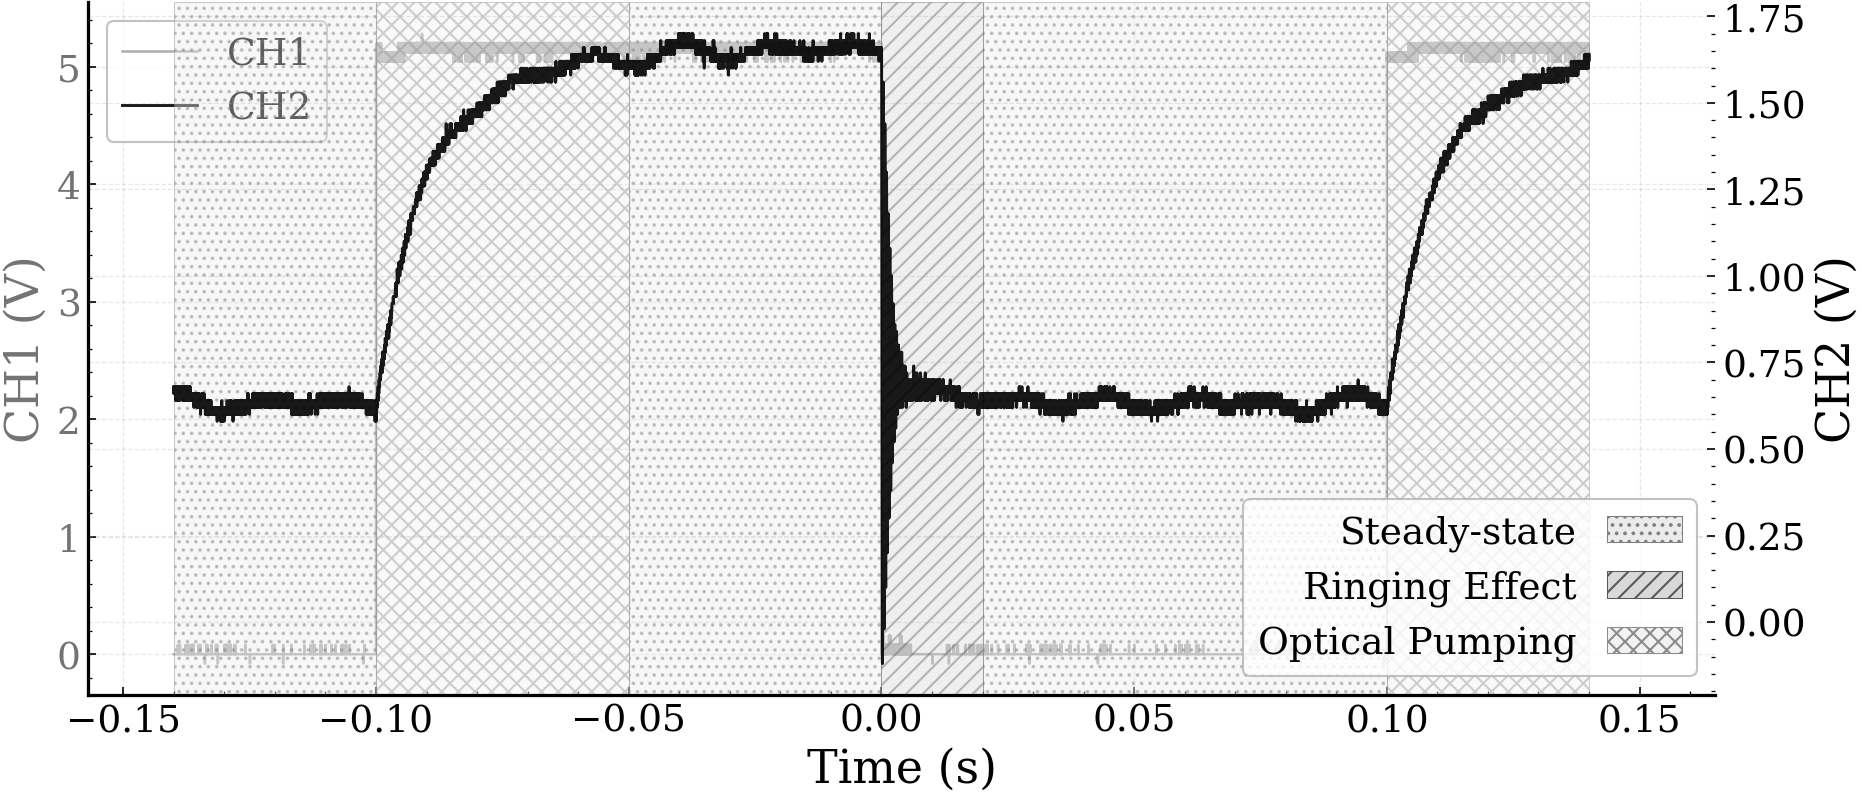

In [6]:
# ── 1. 原始波形繪圖 (BW) ─────────────────────────────────────
df_raw = load_oscilloscope_csv(os.path.join(DATA_DIR, "85_2VPP.csv"))
time_col, ch1_col, ch2_col = df_raw.columns[0], df_raw.columns[1], df_raw.columns[2]

step = max(1, len(df_raw) // DOWNSAMPLE_TARGET)
df_plot = df_raw.iloc[::step].copy()

# 建立 pumping mask
steady_mask = np.zeros(len(df_plot), dtype=bool)
for ts, te in INTERVALS_STEADY:
    steady_mask |= (df_plot[time_col] >= ts) & (df_plot[time_col] <= te)
ringing_mask = np.zeros(len(df_plot), dtype=bool)
for ts, te in INTERVALS_RINGING:
    ringing_mask |= (df_plot[time_col] >= ts) & (df_plot[time_col] <= te)
pumping_mask = ~(steady_mask | ringing_mask)

fig, ax1 = create_figure(
    xlabel="Time (s)", ylabel="CH1 (V)", figsize=(14, 6), style="ppt_bw"
)

ax1.set_ylabel("CH1 (V)", color="0.45")
line1 = ax1.plot(df_plot[time_col], df_plot[ch1_col], label="CH1", **STYLE_CH1)
ax1.tick_params(axis="y", labelcolor="0.45")
ax1.set_xlim(-0.157, 0.165)

ax2 = ax1.twinx()
ax2.set_ylabel("CH2 (V)", color="black")

# ── Hatching 背景區域 ─────────────────────────────────────────
for ts, te in INTERVALS_STEADY:
    ax2.axvspan(
        ts,
        te,
        facecolor=FILL_STEADY,
        hatch=HATCH_STEADY,
        edgecolor=EDGE_STEADY,
        alpha=0.4,
        linewidth=0.5,
    )

for ts, te in INTERVALS_RINGING:
    ax2.axvspan(
        ts,
        te,
        facecolor=FILL_RINGING,
        hatch=HATCH_RINGING,
        edgecolor=EDGE_RINGING,
        alpha=0.4,
        linewidth=0.5,
    )

# Pumping 區間
edges = np.diff(np.concatenate(([0], pumping_mask.values.astype(int), [0])))
starts = np.where(edges == 1)[0]
ends = np.where(edges == -1)[0]
for s, e in zip(starts, ends):
    si, ei = max(0, s), min(len(df_plot) - 1, e - 1)
    ax2.axvspan(
        df_plot[time_col].iloc[si],
        df_plot[time_col].iloc[ei],
        facecolor=FILL_PUMPING,
        hatch=HATCH_PUMPING,
        edgecolor=EDGE_PUMPING,
        alpha=0.4,
        linewidth=0.5,
    )

# CH2
line2 = ax2.plot(df_plot[time_col], df_plot[ch2_col], label="CH2", **STYLE_CH2)
ax2.tick_params(axis="y", labelcolor="black")

# ── 圖例 ─────────────────────────────────────────────────────
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left", frameon=True, edgecolor="0.7")

# Hatching 圖例 patch
p_steady = mpatches.Patch(
    facecolor=FILL_STEADY,
    hatch=HATCH_STEADY,
    edgecolor=EDGE_STEADY,
    label="Steady-state",
    linewidth=0.5,
)
p_ringing = mpatches.Patch(
    facecolor=FILL_RINGING,
    hatch=HATCH_RINGING,
    edgecolor=EDGE_RINGING,
    label="Ringing Effect",
    linewidth=0.5,
)
p_pumping = mpatches.Patch(
    facecolor=FILL_PUMPING,
    hatch=HATCH_PUMPING,
    edgecolor=EDGE_PUMPING,
    label="Optical Pumping",
    linewidth=0.5,
)

ax2.legend(
    handles=[p_steady, p_ringing, p_pumping],
    loc="lower right",
    markerfirst=False,
    frameon=True,
    edgecolor="0.7",
)

save_figure(fig, "4d_CH1_and_CH2_vs_Time_85_2VPP_ppt_bw.pdf", directory=FIG_DIR)
plt.show()

## 2. CH2 穩態傅立葉分析

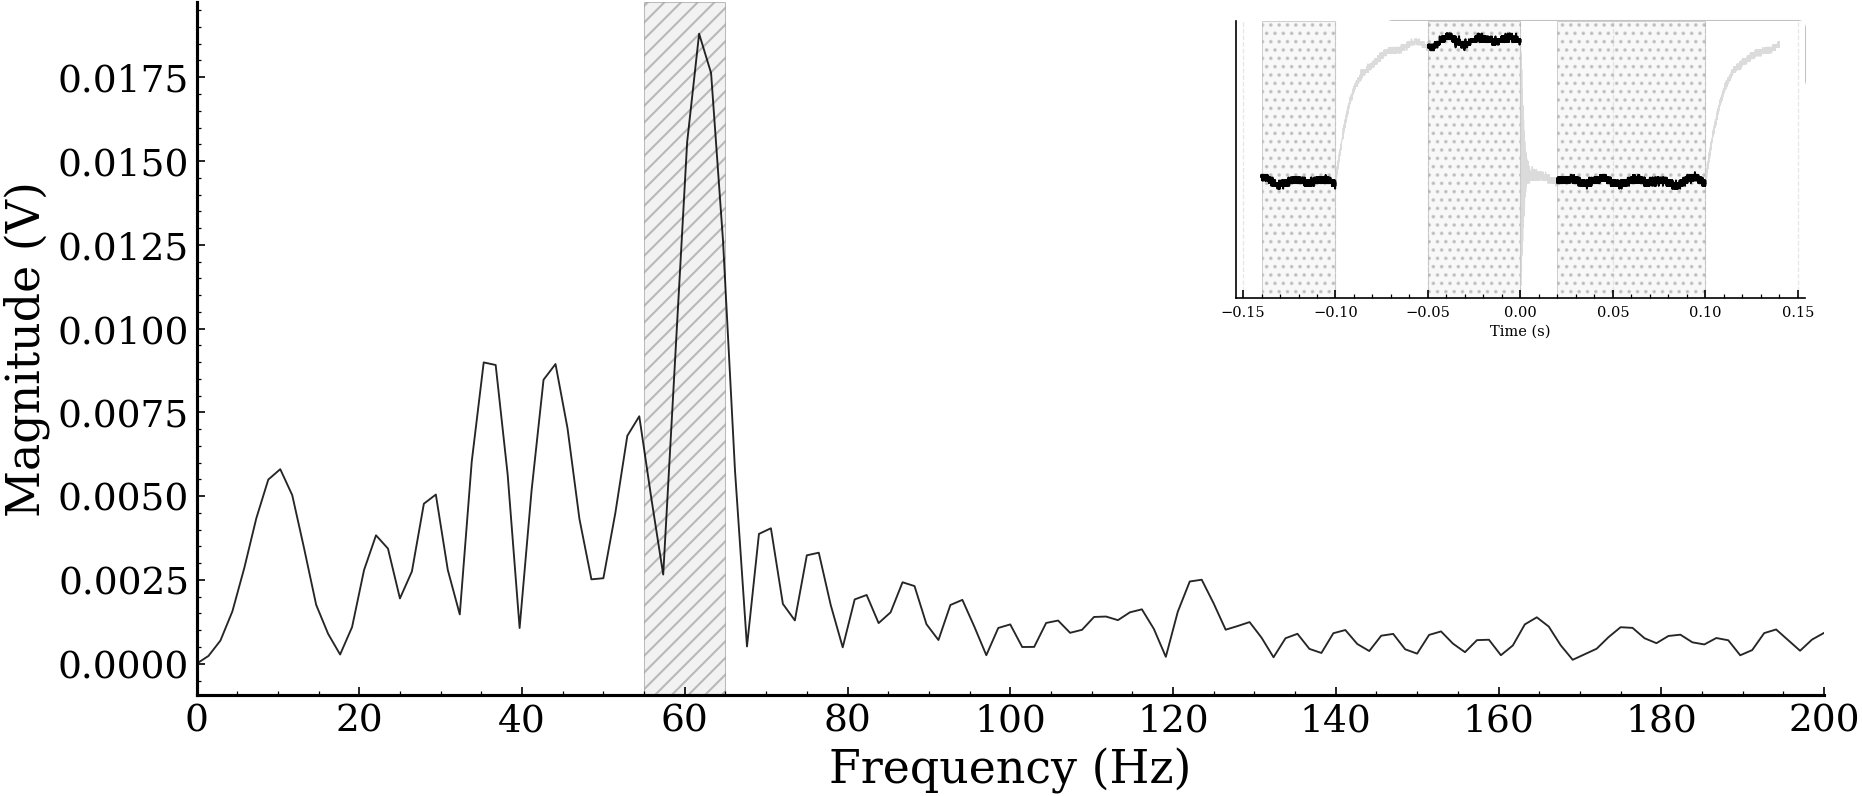

In [7]:
# ── 2. CH2 穩態傅立葉分析 (BW) ──────────────────────────────
intervals = [(-0.14, -0.10), (-0.05, 0.00), (0.02, 0.10)]
pad_factor = 4
f_max_hz = 200.0

time_vals_all = df_raw[time_col].values
ch2_vals_all = df_raw[ch2_col].values

ch2_segments = []
dt = None

for t_start, t_end in intervals:
    mask = (time_vals_all >= t_start) & (time_vals_all <= t_end)
    t_seg, y_seg = time_vals_all[mask], ch2_vals_all[mask]
    if len(t_seg) < 2:
        continue
    if dt is None:
        dt = (t_seg[-1] - t_seg[0]) / (len(t_seg) - 1)
    ch2_segments.append(y_seg - np.mean(y_seg))

combined = np.concatenate(ch2_segments)
n_orig = len(combined)
n_padded = n_orig * pad_factor

fft_vals = np.fft.fft(combined, n=n_padded)
freqs = np.fft.fftfreq(n_padded, d=dt)

pos_mask = freqs >= 0
positive_freqs = freqs[pos_mask][: n_padded // 2]
magnitude = np.abs(fft_vals[pos_mask][: n_padded // 2]) * 2.0 / n_orig

# ── 繪圖 ─────────────────────────────────────────────────────
fig, ax = create_figure(
    xlabel="Frequency (Hz)", ylabel="Magnitude (V)", figsize=(14, 6), style="ppt_bw"
)

ax.plot(positive_freqs, magnitude, color="black", linewidth=0.9, alpha=0.85)
ax.set_xlim(0, f_max_hz)
ax.set_xticks(np.arange(0, f_max_hz + 1, 20))
ax.grid(False)
ax.set_title("")

# 高亮 55–65 Hz 區間 (用 hatching)
ax.axvspan(
    55,
    65,
    facecolor="0.90",
    hatch="///",
    edgecolor="0.5",
    alpha=0.5,
    linewidth=0.5,
    label="55–65 Hz band",
)
ax.legend(loc="upper right", frameon=True, edgecolor="0.7")

# ── Inset: 全時段 CH2 波形，高亮 steady 區段 ─────────────────
add_ch2_inset_bw(
    ax, df_raw, time_col, ch2_col, mode="steady", width="35%", height="40%"
)

save_figure(fig, "4d_CH2_Spectrum_Concatenated_Hz_ppt_bw.pdf", directory=FIG_DIR)
plt.show()

## 3. 單檔 Ringing Fit

Ringing Frequency : (3.04+/-0.00)e+03 Hz
Ringing Period    : (3.29+/-0.00)e-04 s
Decay Rate (γ)    : (7.24+/-0.00)e+02 s⁻¹


/var/folders/5d/w4l2y8995js1b535ll7mb0hr0000gn/T/ipykernel_2006/876841547.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


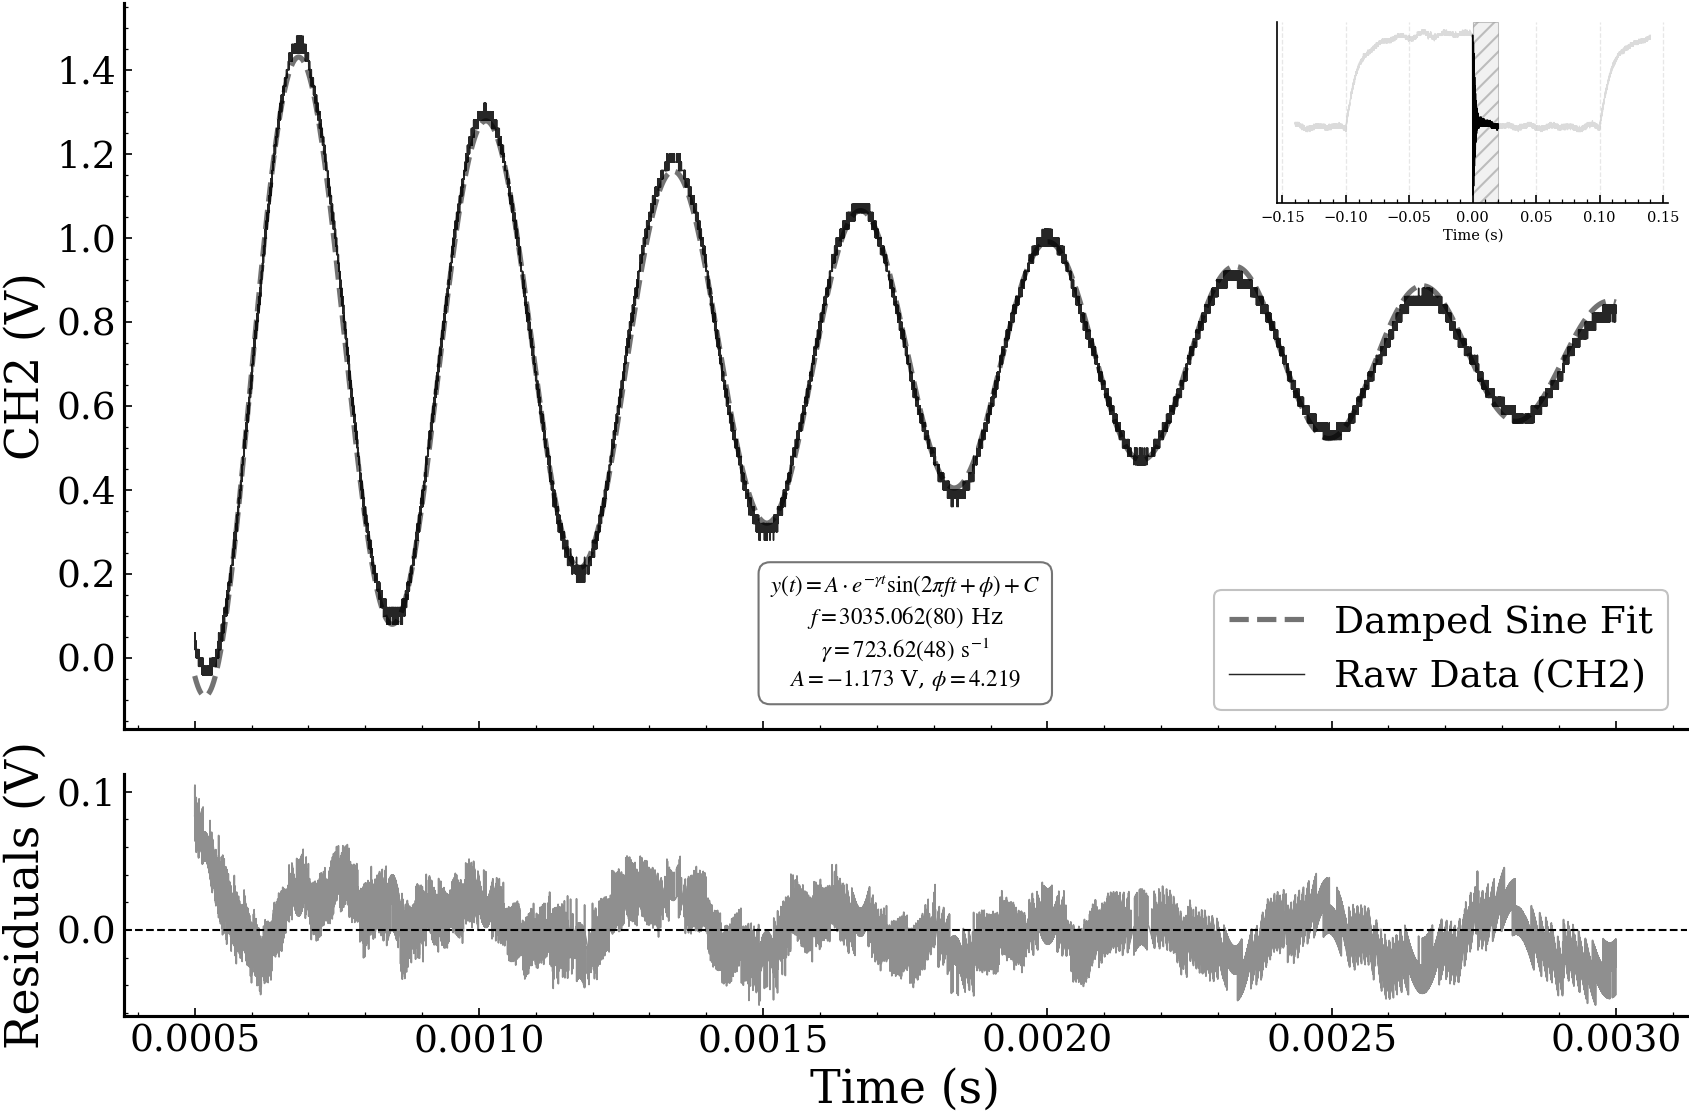

In [ ]:
# ── 3. 單檔 Ringing Fit (BW) ────────────────────────────────
RINGING_RANGE = (0.0005, 0.003)

df_ring = df_raw[
    (df_raw[time_col] >= RINGING_RANGE[0]) & (df_raw[time_col] <= RINGING_RANGE[1])
].reset_index(drop=True)

t_arr = df_ring[time_col].values
y_arr = df_ring[ch2_col].values

C0 = np.mean(y_arr)
A0 = (np.max(y_arr) - np.min(y_arr)) / 2.0
f0, gamma0, phi0 = 4341.0, 500.0, 0.0
p0 = [A0, gamma0, f0, phi0, C0]

popt, pcov = curve_fit(
    damped_sine,
    t_arr,
    y_arr,
    p0=p0,
    bounds=(
        [-np.inf, 0, 1000, -np.inf, -np.inf],
        [np.inf, np.inf, 10000, np.inf, np.inf],
    ),
)

popt_u = correlated_values(popt, pcov)
uf_A, uf_gamma, uf_f, uf_phi, uf_C = popt_u
uf_T = 1.0 / uf_f

print(f"Ringing Frequency : {uf_f:.2e} Hz")
print(f"Ringing Period    : {uf_T:.2e} s")
print(f"Decay Rate (γ)    : {uf_gamma:.2e} s⁻¹")

formula_text = (
    r"$y(t) = A \cdot e^{-\gamma t} \sin(2\pi f t + \phi) + C$" + "\n"
    rf"$f = {ufloat_to_paren(uf_f)}$ Hz" + "\n"
    rf"$\gamma = {ufloat_to_paren(uf_gamma)}$ $\mathrm{{s^{{-1}}}}$" + "\n"
    rf"$A = {uf_A.n:.3f}$ V, $\phi = {uf_phi.n:.3f}$"
)

apply_plot_style("ppt_bw")
fig, (ax_main, ax_res) = plt.subplots(
    2, 1, sharex=True, gridspec_kw={"height_ratios": [3, 1]}, figsize=(14, 6)
)

fitted = damped_sine(t_arr, *popt)

# Fit 曲線先畫 (底層)，Raw data 後畫 (頂層) → 資料不被遮蓋
ax_main.plot(
    t_arr,
    fitted,
    color="0.45",
    linestyle="--",
    linewidth=2.5,
    label="Damped Sine Fit",
    zorder=2,
)
ax_main.plot(
    t_arr,
    y_arr,
    color="black",
    linewidth=0.7,
    alpha=0.85,
    label="Raw Data (CH2)",
    zorder=3,
)

ax_main.text(
    0.5,
    0.05,
    formula_text,
    transform=ax_main.transAxes,
    fontsize=11,
    va="bottom",
    ha="center",
    bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.9, ec="0.4"),
)
ax_main.set_ylabel("CH2 (V)")
ax_main.legend(loc="lower right", frameon=True, edgecolor="0.7")
ax_main.grid(False)

# ── Inset ─────────────────────────────────────────────────────
add_ch2_inset_bw(
    ax_main, df_raw, time_col, ch2_col, mode="ringing", width="25%", height="25%"
)

residuals = y_arr - fitted
ax_res.plot(t_arr, residuals, color="0.45", linewidth=0.8, alpha=0.8)
ax_res.axhline(0, color="black", ls="--", lw=1)
ax_res.set_xlabel("Time (s)")
ax_res.set_ylabel("Residuals (V)")
ax_res.grid(False)

fig.tight_layout()
save_figure(fig, "4d_CH2_Ringing_Fit_with_Residuals_ppt_bw.pdf", directory=FIG_DIR)
plt.show()

## 4. 批次 Ringing Fit

In [9]:
# ── 4. 批次 Ringing Fit ──────────────────────────────────────


def process_ringing_fit(filepath: str, time_range: tuple = (0.0005, 0.003)):
    df = load_oscilloscope_csv(filepath)
    tcol, ycol = df.columns[0], df.columns[2]
    mask = (df[tcol] >= time_range[0]) & (df[tcol] <= time_range[1])
    df_seg = df[mask].reset_index(drop=True)
    t = df_seg[tcol].values
    y = df_seg[ycol].values
    if len(t) < 10:
        return np.nan, np.nan
    C0 = np.mean(y)
    A0 = (np.max(y) - np.min(y)) / 2.0
    dt_approx = (t[-1] - t[0]) / len(t) if len(t) > 1 else 1e-5
    min_dist = max(1, int(20e-6 / dt_approx))
    peaks, _ = find_peaks(y, prominence=A0 * 0.2, distance=min_dist)
    f0 = (
        np.clip(1.0 / np.mean(np.diff(t[peaks])), 100, 20000)
        if len(peaks) > 1
        else 4000.0
    )
    p0 = [A0, 500.0, f0, 0.0, C0]
    try:
        popt, pcov = curve_fit(
            damped_sine,
            t,
            y,
            p0=p0,
            bounds=(
                [-np.inf, 0, 100, -np.inf, -np.inf],
                [np.inf, np.inf, 20000, np.inf, np.inf],
            ),
        )
        uf_T = 1.0 / correlated_values(popt, pcov)[2]
        return uf_T.n, uf_T.s
    except Exception as e:
        print(f"擬合失敗: {filepath} — {e}")
        return np.nan, np.nan


isotopes = ["85", "87"]
voltages = [1, 2, 3]
results = []

for iso in isotopes:
    for v in voltages:
        files = glob.glob(os.path.join(DATA_DIR, f"{iso}_{v}V*"))
        if not files:
            continue
        T_sec, T_std = process_ringing_fit(files[0])
        if np.isnan(T_sec):
            continue
        results.append(
            {
                "Isotope": f"Rb-{iso}",
                "Peak RF (Vpp)": v,
                "Period T (ms)": T_sec * 1e3,
                "σ_T (ms)": T_std * 1e3,
                "Period T (μs)": T_sec * 1e6,
                "σ_T (μs)": T_std * 1e6,
            }
        )

df_results = pd.DataFrame(results)
print("=" * 56)
print("  Extracted Ringing Periods via Damped Sine Fit")
print("=" * 56)
if not df_results.empty:
    display(df_results[["Isotope", "Peak RF (Vpp)", "Period T (ms)", "σ_T (ms)"]])
else:
    print("未找到有效擬合結果，請檢查資料或參數。")

  Extracted Ringing Periods via Damped Sine Fit


,Isotope,Peak RF (Vpp),Period T (ms),σ_T (ms)
0,Rb-85,1,0.666842,0.000077
1,Rb-85,2,0.329483,0.000009
2,Rb-85,3,0.232083,0.000004
3,Rb-87,1,0.965218,0.000058
4,Rb-87,2,0.489017,0.000013
5,Rb-87,3,0.344124,0.000006


## 5. Period vs Peak RF 繪圖與反比擬合

=== Ratio of a (Rb-87 / Rb-85) ===
1.42+/-0.10



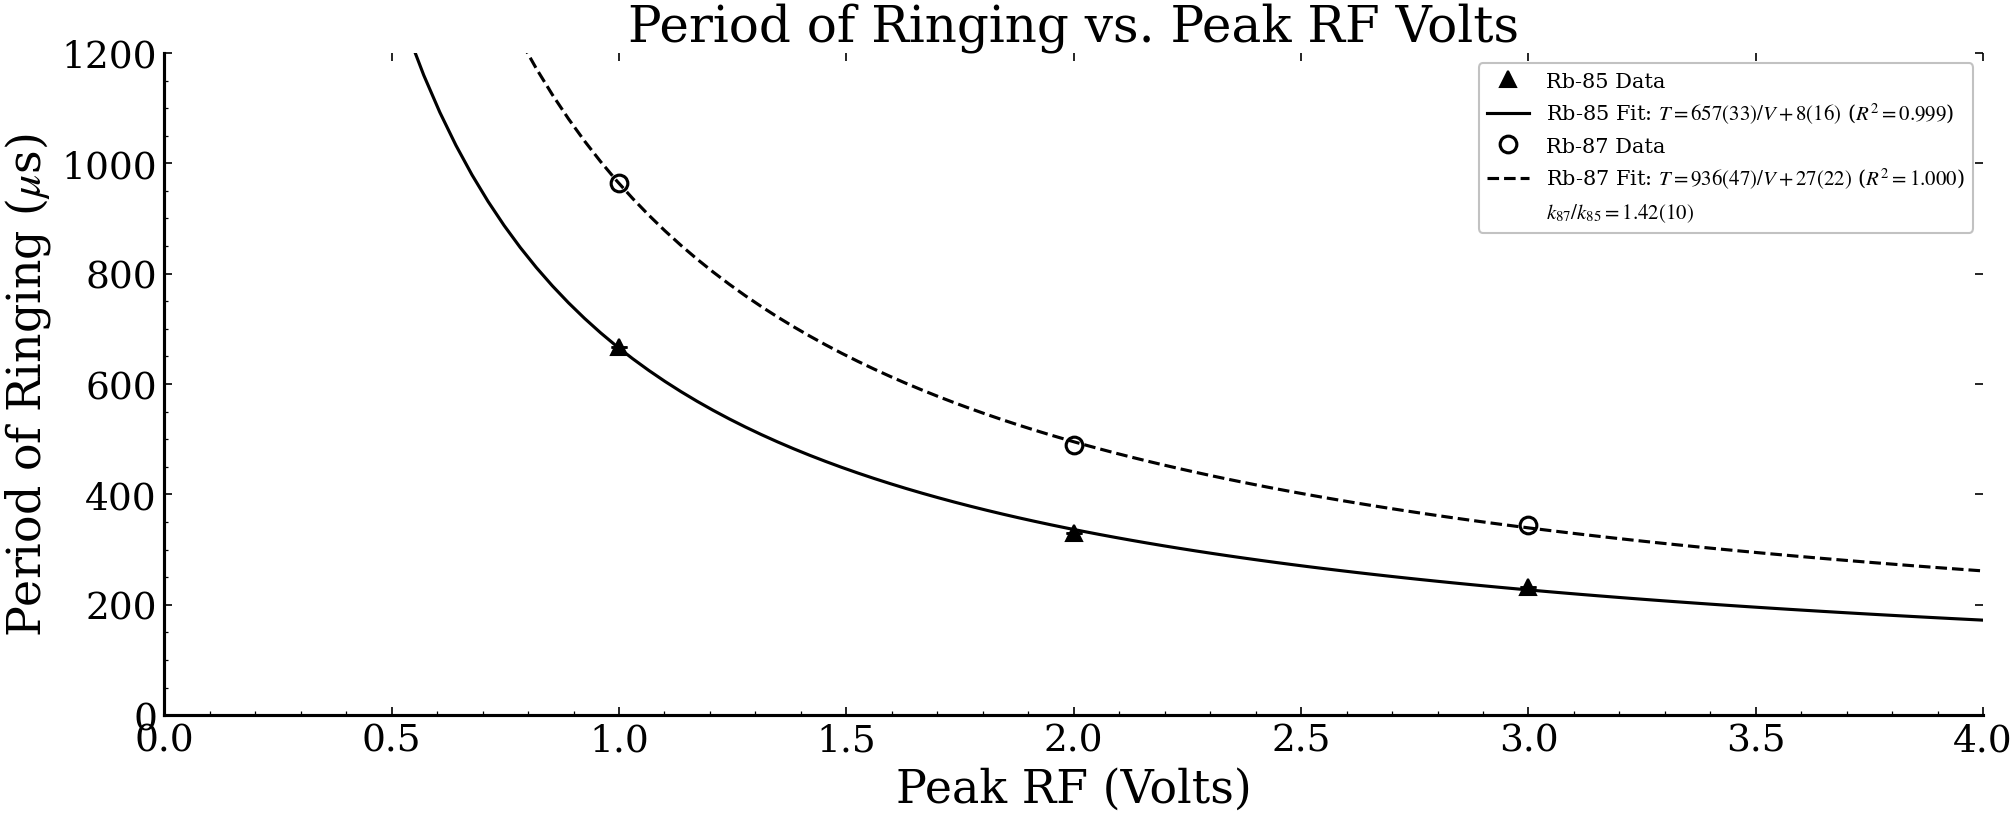

In [10]:
# ── 5. Period vs Peak RF (BW) ────────────────────────────────
apply_plot_style("ppt_bw")
fig, ax = plt.subplots(figsize=(14, 6))

# 黑白區分兩種同位素：不同 marker + 填充/空心
MARKERS_BW = {
    "Rb-85": dict(
        marker="^", markerfacecolor="black", markeredgecolor="black", markersize=8
    ),
    "Rb-87": dict(
        marker="o",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=8,
        markeredgewidth=1.5,
    ),
}
LINESTYLES_BW = {"Rb-85": "-", "Rb-87": "--"}

v_fit = np.linspace(0.5, 4.0, 100)
k_uf_dict = {}

for iso in df_results["Isotope"].unique():
    sub = df_results[df_results["Isotope"] == iso]
    X = sub["Peak RF (Vpp)"].values
    Y = sub["Period T (μs)"].values
    Y_err = sub["σ_T (μs)"].values

    mk = MARKERS_BW[iso]
    ax.errorbar(
        X,
        Y,
        yerr=Y_err,
        fmt="none",
        ecolor="black",
        capsize=4,
        capthick=1.2,
        elinewidth=1.2,
    )
    ax.plot(X, Y, linestyle="None", label=f"{iso} Data", **mk)

    if len(X) < 2:
        continue

    sigma_V = [0.030, 0.060, 0.090]
    try:
        a_uf, b_uf, fit_res = inverse_linear_regression_with_propagation(
            X, Y, sigma_V, Y_err
        )
        k_uf_dict[iso] = a_uf

        ss_res = np.sum(fit_res["residuals"] ** 2)
        ss_tot = np.sum((Y - np.mean(Y)) ** 2)
        r2 = 1 - ss_res / ss_tot

        ls = LINESTYLES_BW[iso]
        label = f"{iso} Fit: $T = {ufloat_to_paren(a_uf)}/V + {ufloat_to_paren(b_uf)}$ ($R^2={r2:.3f}$)"
        ax.plot(
            v_fit,
            a_uf.n / v_fit + b_uf.n,
            ls=ls,
            color="black",
            linewidth=1.5,
            label=label,
        )
    except Exception as e:
        print(f"擬合失敗 ({iso}): {e}")

if "Rb-87" in k_uf_dict and "Rb-85" in k_uf_dict:
    ratio = k_uf_dict["Rb-87"] / k_uf_dict["Rb-85"]
    print(f"=== Ratio of a (Rb-87 / Rb-85) ===")
    print(f"{ratio}\n")
    ax.plot([], [], " ", label=rf"$k_{{87}} / k_{{85}} = {ufloat_to_paren(ratio)}$")

ax.set(
    xlabel="Peak RF (Volts)",
    ylabel=r"Period of Ringing ($\mu$s)",
    title="Period of Ringing vs. Peak RF Volts",
    xlim=(0, 4),
    ylim=(0, 1200),
)
ax.legend(fontsize=10, loc="upper right", frameon=True, edgecolor="0.7")
ax.tick_params(direction="in", top=True, right=True)
ax.grid(False)
plt.tight_layout()
save_figure(fig, "4d_Period_vs_Peak_RF_ppt_bw.pdf", directory=FIG_DIR)
plt.show()

## 6. Optical Pumping Time Constant (τ_p)

  Optical Pumping Time Constant (2VPP)
  Rb-85: τ_p = 10.387 ± 0.001 ms
  Rb-87: τ_p = 12.464 ± 0.002 ms
  Fit range: -0.1 to 0.0 s


/var/folders/5d/w4l2y8995js1b535ll7mb0hr0000gn/T/ipykernel_2006/880991079.py:176: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


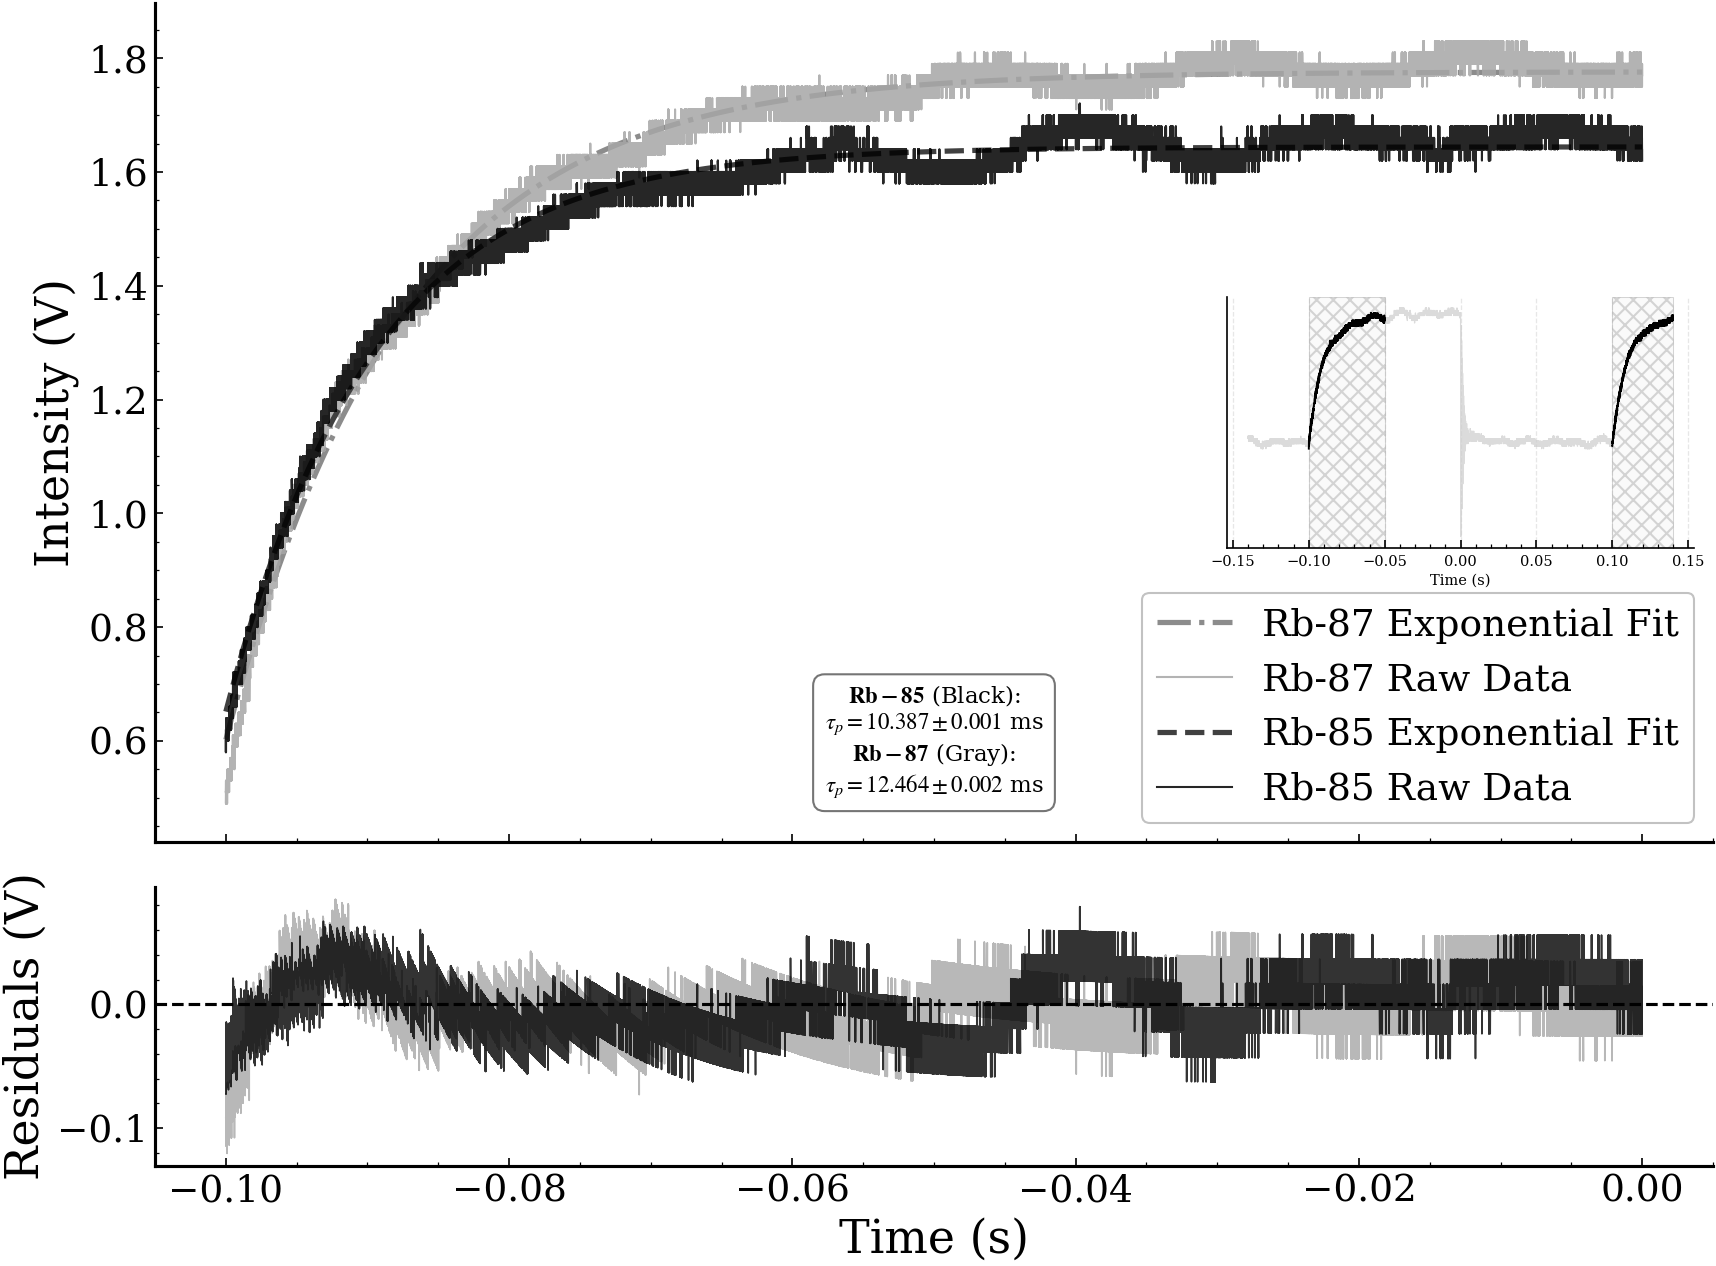

In [ ]:
# ── 6. Optical Pumping Time Constant (BW) ───────────────────
FIT_START, FIT_END = -0.10, 0.00
CONTEXT_START, CONTEXT_END = -0.10, 0.00


def get_op_data(filename):
    df_op = load_oscilloscope_csv(os.path.join(DATA_DIR, filename))
    tcol_op, ycol_op = df_op.columns[0], df_op.columns[2]

    ctx_mask = (df_op[tcol_op] >= CONTEXT_START) & (df_op[tcol_op] <= CONTEXT_END)
    t_context = df_op.loc[ctx_mask, tcol_op].values
    y_context = df_op.loc[ctx_mask, ycol_op].values

    fit_mask = (df_op[tcol_op] >= FIT_START) & (df_op[tcol_op] <= FIT_END)
    t_fit = df_op.loc[fit_mask, tcol_op].values
    y_fit = df_op.loc[fit_mask, ycol_op].values
    t_shifted = t_fit - FIT_START

    C0_op = np.max(y_fit)
    A0_op = C0_op - np.min(y_fit)
    popt_op, pcov_op = curve_fit(
        optical_pumping_model, t_shifted, y_fit, p0=[C0_op, A0_op, 0.02]
    )
    uf_C_op, uf_A_op, uf_tau = correlated_values(popt_op, pcov_op)

    return (
        df_op,
        tcol_op,
        ycol_op,
        t_context,
        y_context,
        t_fit,
        y_fit,
        t_shifted,
        popt_op,
        uf_tau,
        uf_C_op,
        uf_A_op,
    )


# 讀取 85 與 87 檔案
(
    df_85,
    tcol_85,
    ycol_85,
    t_ctx_85,
    y_ctx_85,
    t_fit_85,
    y_fit_85,
    t_shift_85,
    popt_85,
    tau_85,
    C_85,
    A_85,
) = get_op_data("85_2VPP.csv")
(
    df_87,
    tcol_87,
    ycol_87,
    t_ctx_87,
    y_ctx_87,
    t_fit_87,
    y_fit_87,
    t_shift_87,
    popt_87,
    tau_87,
    C_87,
    A_87,
) = get_op_data("87_2VPP.csv")

tau_ms_85 = tau_85 * 1000
tau_ms_87 = tau_87 * 1000

print("=" * 44)
print("  Optical Pumping Time Constant (2VPP)")
print("=" * 44)
print(f"  Rb-85: τ_p = {tau_ms_85.n:.3f} ± {tau_ms_85.s:.3f} ms")
print(f"  Rb-87: τ_p = {tau_ms_87.n:.3f} ± {tau_ms_87.s:.3f} ms")
print(f"  Fit range: {FIT_START} to {FIT_END} s")
print("=" * 44)

# ── 繪圖 ─────────────────────────────────────────────────────
apply_plot_style("ppt_bw")
fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, gridspec_kw={"height_ratios": [3, 1]}, figsize=(12, 9)
)

y_fit_curve_85 = optical_pumping_model(t_shift_85, *popt_85)
y_fit_curve_87 = optical_pumping_model(t_shift_87, *popt_87)

# 畫 Rb-87 (較淺灰)
ax1.plot(
    t_fit_87,
    y_fit_curve_87,
    color="0.55",
    linestyle="-.",
    linewidth=2.5,
    label="Rb-87 Exponential Fit",
    zorder=2,
)
ax1.plot(
    t_ctx_87,
    y_ctx_87,
    color="0.65",
    linewidth=1.0,
    alpha=0.85,
    label="Rb-87 Raw Data",
    zorder=3,
)

# 畫 Rb-85 (黑色)
ax1.plot(
    t_fit_85,
    y_fit_curve_85,
    color="0.25",
    linestyle="--",
    linewidth=2.5,
    label="Rb-85 Exponential Fit",
    zorder=4,
)
ax1.plot(
    t_ctx_85,
    y_ctx_85,
    color="black",
    linewidth=1.0,
    alpha=0.85,
    label="Rb-85 Raw Data",
    zorder=5,
)

box_str = (
    r"$\bf{Rb-85}$" + " (Black):\n"
    f"$\\tau_p = {tau_ms_85.n:.3f} \\pm {tau_ms_85.s:.3f}$ ms\n"
    r"$\bf{Rb-87}$" + " (Gray):\n"
    f"$\\tau_p = {tau_ms_87.n:.3f} \\pm {tau_ms_87.s:.3f}$ ms"
)
ax1.text(
    0.5,
    0.05,
    box_str,
    transform=ax1.transAxes,
    fontsize=11,
    va="bottom",
    ha="center",
    bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.9, ec="0.4"),
)
ax1.set_ylabel("Intensity (V)")
ax1.set_title("")
ax1.legend(loc="lower right", frameon=True, edgecolor="0.7")
ax1.grid(False)

# ── Inset: pumping 區段高亮 (保留 85 的圖中圖) ─────────────────
add_ch2_inset_bw(
    ax1,
    df_85,
    tcol_85,
    ycol_85,
    loc="center right",
    mode="pumping",
    width="30%",
    height="30%",
)

residuals_85 = y_fit_85 - y_fit_curve_85
residuals_87 = y_fit_87 - y_fit_curve_87

# Residuals 也對應分色
ax2.plot(t_fit_87, residuals_87, color="0.65", linewidth=0.8, alpha=0.8)
ax2.plot(t_fit_85, residuals_85, color="black", linewidth=0.8, alpha=0.8)
ax2.axhline(0, color="black", ls="--", lw=1.5)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Residuals (V)")
ax2.grid(False)

fig.tight_layout()
save_figure(fig, "4d_Optical_Pumping_Recovery_85_87_2VPP_ppt_bw.pdf", directory=FIG_DIR)
plt.show()

根據 Teachspin 手冊 Section 2G 的理論，RF 關閉後的光學 pumping 恢復時間常數 τ_p 原則上由 pumping light 的強度決定，而不是 RF 振幅。但你可以檢驗：在不同 RF 峰值（1, 2, 3V）下，τ_p 是否真的保持一致？如果 τ_p 隨 RF 振幅改變，這可能暗示 RF 關閉不夠乾淨，或存在殘餘磁場效應。

,Isotope,Peak RF (Vpp),tau_p (ms),tau_p_err (ms)
0,Rb-85,1,10.719541,0.001783
1,Rb-85,2,10.386501,0.001370
2,Rb-85,3,10.317454,0.001332
3,Rb-87,1,13.067838,0.001502
4,Rb-87,2,12.464326,0.001522
5,Rb-87,3,12.077464,0.001323


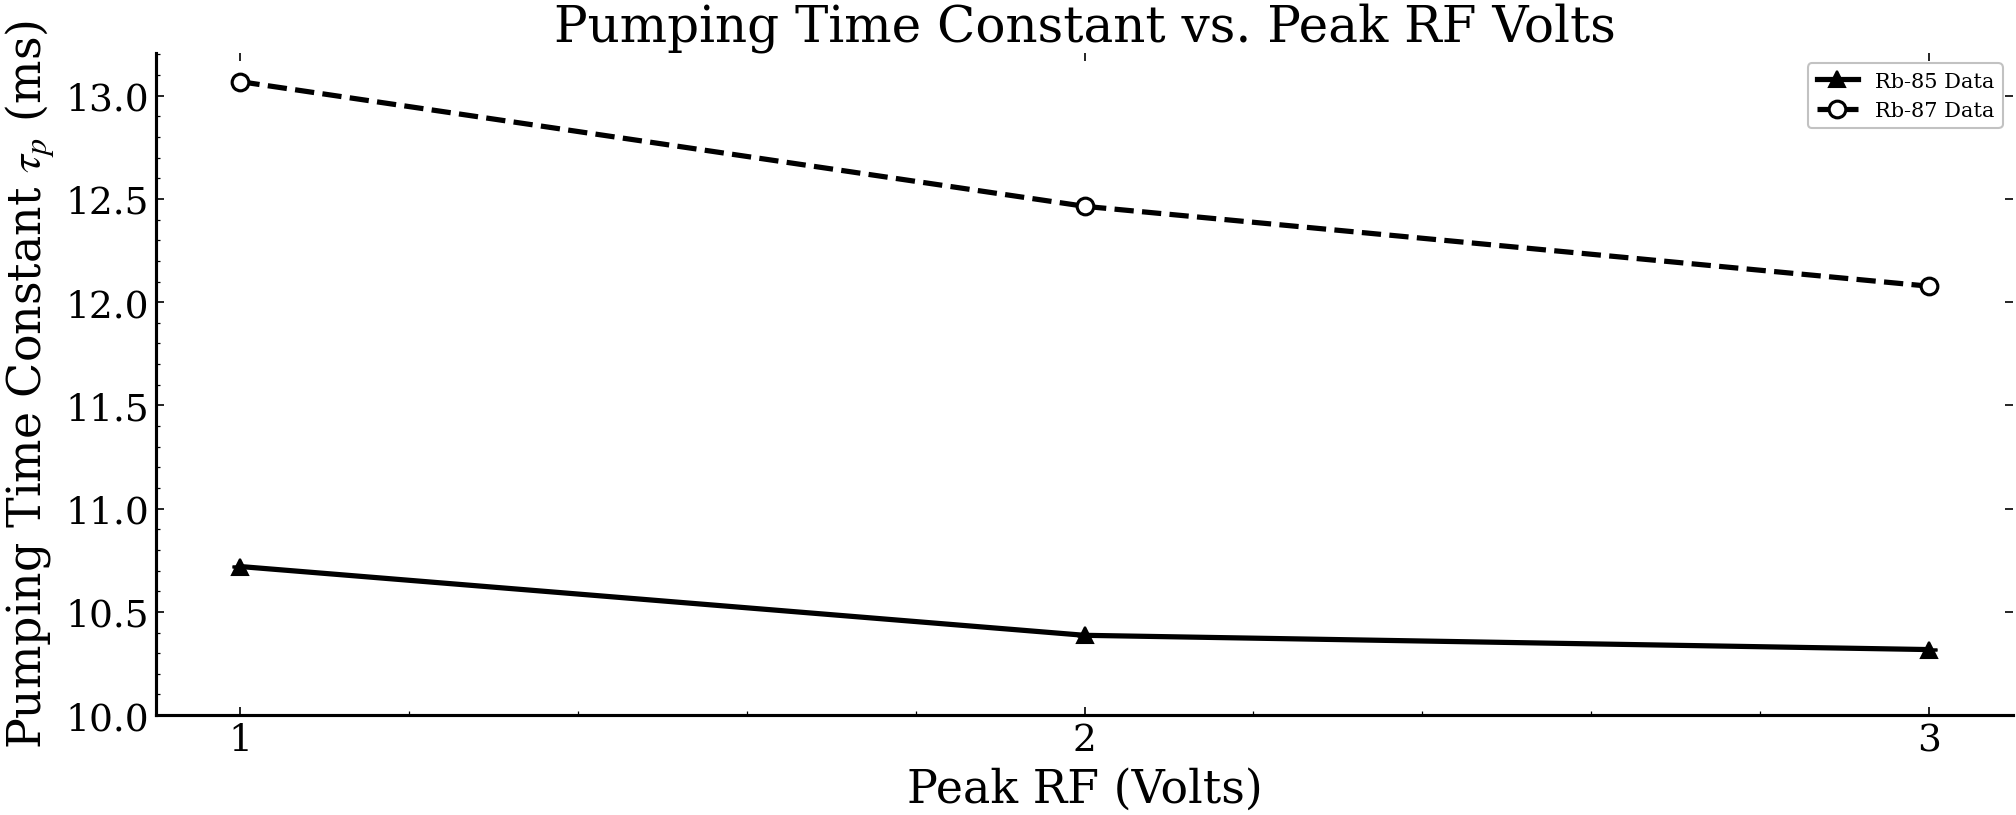

In [12]:
# ── 7. Pumping Time Constant vs Peak RF (BW) ───────────────────
FIT_START, FIT_END = -0.10, 0.00

tau_results = []
isotopes_op = ["85", "87"]
voltages_op = [1, 2, 3]

for iso in isotopes_op:
    for v in voltages_op:
        pattern = os.path.join(DATA_DIR, f"{iso}_{v}V*.csv")
        files = glob.glob(pattern)
        if not files:
            continue
        filepath = files[0]

        df = load_oscilloscope_csv(filepath)
        tcol, ycol = df.columns[0], df.columns[2]

        fit_mask = (df[tcol] >= FIT_START) & (df[tcol] <= FIT_END)
        t_fit = df.loc[fit_mask, tcol].values
        y_fit = df.loc[fit_mask, ycol].values

        if len(t_fit) < 10:
            continue

        t_shifted = t_fit - FIT_START
        C0_op = np.max(y_fit)
        A0_op = C0_op - np.min(y_fit)

        try:
            popt_op, pcov_op = curve_fit(
                optical_pumping_model, t_shifted, y_fit, p0=[C0_op, A0_op, 0.02]
            )
            uf_tau = correlated_values(popt_op, pcov_op)[2]
            tau_results.append(
                {
                    "Isotope": f"Rb-{iso}",
                    "Peak RF (Vpp)": v,
                    "tau_p (ms)": uf_tau.n * 1000,
                    "tau_p_err (ms)": uf_tau.s * 1000,
                }
            )
        except Exception as e:
            print(f"Failed to fit {filepath}: {e}")

df_tau = pd.DataFrame(tau_results)
display(df_tau)

# ── 繪圖 ─────────────────────────────────────────────────────
apply_plot_style("ppt_bw")
fig, ax = plt.subplots(figsize=(14, 6))

for iso in df_tau["Isotope"].unique():
    sub = df_tau[df_tau["Isotope"] == iso]
    X = sub["Peak RF (Vpp)"].values
    Y = sub["tau_p (ms)"].values
    Y_err = sub["tau_p_err (ms)"].values

    mk = MARKERS_BW[iso]
    ls = LINESTYLES_BW[iso]

    ax.errorbar(
        X,
        Y,
        yerr=Y_err,
        fmt="none",
        ecolor="black",
        capsize=4,
        capthick=1.2,
        elinewidth=1.2,
    )
    ax.plot(X, Y, ls=ls, color="black", label=f"{iso} Data", **mk)

ax.set(
    xlabel="Peak RF (Volts)",
    ylabel=r"Pumping Time Constant $\tau_p$ (ms)",
    title="Pumping Time Constant vs. Peak RF Volts",
    xticks=[1, 2, 3],
)
# Start y-axis from 0 to show relative variation
ax.set_ylim(bottom=10)
ax.legend(fontsize=10, loc="upper right", frameon=True, edgecolor="0.7")
ax.tick_params(direction="in", top=True, right=True)
ax.grid(False)

plt.tight_layout()
save_figure(fig, "4d_Pumping_Time_Constant_vs_Peak_RF_ppt_bw.pdf", directory=FIG_DIR)
plt.show()